### TEM Image Segmentation and Feature Size Analysis

Workflow: Constrast-based Clustering and Morphological Measurement of Nanoscale Features

In [1]:
# ------------------------------------------------------------
# Author:        Nitish Ranjan Sarker
# Affiliation:   Stanford University / SLAC National Accelerator Laboratory
# Project:       TEM-based characterization of nanoscale circular CEM features
#                using unsupervised segmentation
# Version:       v1.0.6
# Last Updated:  06-15-2026
# License:       Internal research use / extendable to open scientific workflows
# ------------------------------------------------------------

In [2]:
# Check and install necessary packages
import importlib
import subprocess
import sys

packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-image": "skimage",
    "scikit-learn": "sklearn",
    "opencv-python": "cv2",
    "openpyxl": "openpyxl",
}

for pip_name, import_name in packages.items():
    try:
        importlib.import_module(import_name)
        #print(f"{pip_name} OK")
    except ImportError:
        print(f"Installing {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

In [3]:
# Load libraries
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import io, color, exposure, filters, morphology, measure, segmentation
from sklearn.cluster import KMeans
import cv2
from tem_seg_utils import *

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
# Paths
input_folder = "TEM_images"
output_folder = "TEM_output"
os.makedirs(input_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

print("Ready. Upload images into TEM_images/ or use the uploader cell below.")

Ready. Upload images into TEM_images/ or use the uploader cell below.


In [5]:
#!pip install ipywidgets
from ipywidgets import FileUpload
from IPython.display import display

uploader = FileUpload(accept='.png,.jpg,.jpeg,.tif,.tiff', multiple=True)
display(uploader)

def save_uploads(uploader, folder):
    os.makedirs(folder, exist_ok=True)

    uploaded_files = uploader.value

    count = 0

    for fileinfo in uploaded_files:
        filename = fileinfo["name"]
        content = fileinfo["content"]

        # content may be a memoryview, so convert to bytes
        if isinstance(content, memoryview):
            content = content.tobytes()

        output_path = os.path.join(folder, filename)

        with open(output_path, "wb") as f:
            f.write(content)

        count += 1

    print(f"Saved {count} file(s) to {folder}/")



FileUpload(value=(), accept='.png,.jpg,.jpeg,.tif,.tiff', description='Upload', multiple=True)

In [6]:
save_uploads(uploader, input_folder)

Saved 6 file(s) to TEM_images/


In [7]:
# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
# Image scale
fov_nm_x = 100
fov_nm_y = 100

# KMeans settings
n_classes = 4
random_state = 50

# Population selection
# Options:
#   "darkest_only"
#   "darkest_plus_second"
population_mode = "darkest_only"

# Feature filtering
size_filter_column = "equivalent_diameter_nm" #"feret_diameter_max_nm" or "equivalent_diameter_nm"
size_column_for_colormap = "equivalent_diameter_nm"

min_feature_size_nm = 3
max_feature_size_nm = None

# Population-level filter
min_features_required = 25

# Summary-level filter
min_features_for_summary = 25
min_median_size_for_summary = 3

# Preprocessing
use_clahe = True
use_smoothing = False
smoothing_method = "gaussian"
gaussian_sigma = 0.5
median_radius = 1
clip_limit = 0.02

# Output display
remove_border = False
max_images = 6
display_images = True

# Overlay settings
domain_alpha = 0.70
mask_alpha = 0.45

# Optional annotation overlay
make_number_or_circle_overlay = False
annotation_mode = "circle"  # "number" or "circle"

In [8]:
# ------------------------------------------------------------
# Load and sort images by desired sample order
# ------------------------------------------------------------

# Desired reporting order
sample_order = [
    "Backbone random",
    "Sidechain random 1.5",
    "Sidechain random 1.8",
    "Sidechain block",
    "Backbone block",
    "Nafion 212"
]

# Load all images
image_paths = (
    glob.glob(os.path.join(input_folder, "*.png"))
    + glob.glob(os.path.join(input_folder, "*.tif"))
    + glob.glob(os.path.join(input_folder, "*.tiff"))
    + glob.glob(os.path.join(input_folder, "*.jpg"))
    + glob.glob(os.path.join(input_folder, "*.jpeg"))
)

# Function to extract sample name from filename
def extract_sample_name(path):
    name = os.path.splitext(os.path.basename(path))[0]
    return name

# Sort according to predefined order
image_paths_sorted = sorted(
    image_paths,
    key=lambda p: (
        sample_order.index(extract_sample_name(p))
        if extract_sample_name(p) in sample_order
        else len(sample_order)
    )
)

# Apply max_images limit after sorting
image_paths = image_paths_sorted[:max_images]

print(f"Found {len(image_paths)} image(s) in desired order:\n")

for path in image_paths:
    print(os.path.basename(path))

Found 6 image(s) in desired order:

Backbone random.png
Sidechain random 1.5.png
Sidechain random 1.8.png
Sidechain block.png
Backbone block.png
Nafion 212.png


In [9]:
# ------------------------------------------------------------
# Global darkness sanity check
# ------------------------------------------------------------
use_kmeans_darkness_threshold = False

darkness_metric = "p90"
darkness_threshold_percentile = 95

darkest_threshold, df_darkest_metrics = estimate_kmeans_dark_cluster_threshold(
    image_paths=image_paths,
    read_func=read_grayscale_image,
    preprocess_func=contrast_preprocess,
    segment_func=kmeans_segment_classes,
    n_classes=n_classes,
    random_state=random_state,
    selected_rank=1,
    metric=darkness_metric,
    threshold_percentile=darkness_threshold_percentile,
    use_clahe=use_clahe,
    use_smoothing=use_smoothing,
    smoothing_method=smoothing_method,
    gaussian_sigma=gaussian_sigma,
    median_radius=median_radius,
    clip_limit=clip_limit
)

print("Darkest-cluster threshold:", darkest_threshold)
df_darkest_metrics

Darkest-cluster threshold: 0.27835291584363764


,image,selected_rank,kmeans_class_id,darkness_metric,cluster_mean_intensity,cluster_pixel_fraction
0,Backbone random,1,2,0.259336,0.158875,0.204046
1,Sidechain random 1.5,1,2,0.248211,0.148019,0.212314
2,Sidechain random 1.8,1,1,0.229467,0.128968,0.238728
3,Sidechain block,1,2,0.284692,0.182293,0.195538
4,Backbone block,1,3,0.226895,0.125633,0.243848
5,Nafion 212,1,3,0.229336,0.128414,0.244810


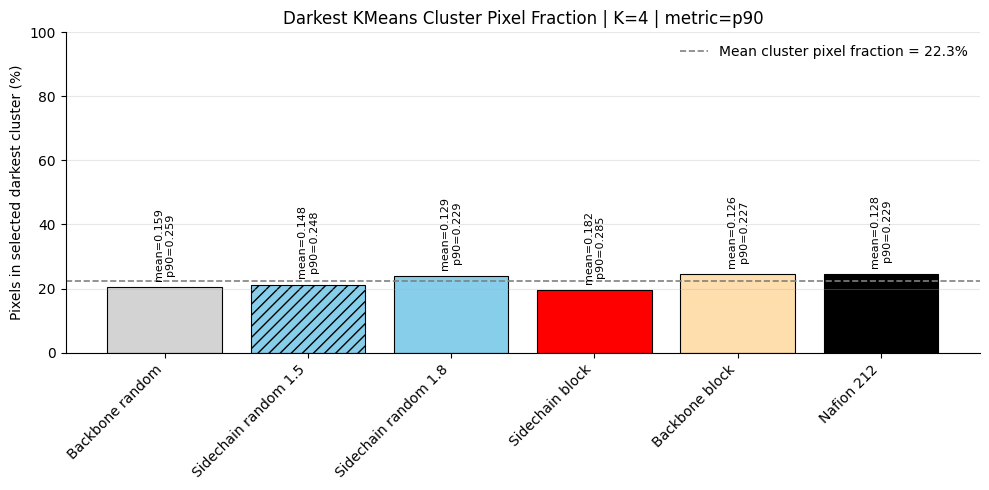

In [10]:
# ------------------------------------------------------------
# Plot darkest-cluster pixel fraction with intensity annotation
# using same sample colors as other plots
# ------------------------------------------------------------

df_plot = df_darkest_metrics.copy()

# Convert fraction to percent
df_plot["cluster_pixel_percent"] = 100 * df_plot["cluster_pixel_fraction"]

# Sort by image order from image_paths
image_order = [
    os.path.splitext(os.path.basename(p))[0]
    for p in image_paths
]

df_plot["image"] = pd.Categorical(
    df_plot["image"],
    categories=image_order,
    ordered=True
)

df_plot = df_plot.sort_values("image").copy()
df_plot["image"] = df_plot["image"].astype(str)

# Same sample colors used in the other summary plots
sample_style = {
    "Backbone random": {"color": "lightgray", "hatch": None},
    "Sidechain random 1.5": {"color": "skyblue", "hatch": "///"},
    "Sidechain random 1.8": {"color": "skyblue", "hatch": None},
    "Sidechain block": {"color": "red", "hatch": None},
    "Backbone block": {"color": "navajowhite", "hatch": None},
    "Nafion 212": {"color": "black", "hatch": None},
}

bar_colors = [
    sample_style.get(str(name), {"color": "gray"})["color"]
    for name in df_plot["image"]
]

bar_hatches = [
    sample_style.get(str(name), {"hatch": None})["hatch"]
    for name in df_plot["image"]
]

x = np.arange(len(df_plot))

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    x,
    df_plot["cluster_pixel_percent"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

# Apply hatch pattern where needed
for bar, hatch in zip(bars, bar_hatches):
    if hatch is not None:
        bar.set_hatch(hatch)

# Annotate each bar with cluster mean intensity and p90 metric
for i, row in df_plot.reset_index(drop=True).iterrows():
    pixel_percent = row["cluster_pixel_percent"]
    mean_intensity = row["cluster_mean_intensity"]
    darkness_metric_value = row["darkness_metric"]

    annotation_text = (
        f"mean={mean_intensity:.3f}\n"
        f"p90={darkness_metric_value:.3f}"
    )

    ax.text(
        i,
        pixel_percent + 2,
        annotation_text,
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

ax.axhline(
    df_plot["cluster_pixel_percent"].mean(),
    linestyle="--",
    linewidth=1.2,
    color="gray",
    label=(
        f"Mean cluster pixel fraction = "
        f"{df_plot['cluster_pixel_percent'].mean():.1f}%"
    )
)

ax.set_xticks(x)
ax.set_xticklabels(
    df_plot["image"],
    rotation=45,
    ha="right"
)

# Force y-axis from 0 to 100%
ax.set_ylim(0, 100)

ax.set_ylabel("Pixels in selected darkest cluster (%)")
ax.set_title(
    f"Darkest KMeans Cluster Pixel Fraction | "
    f"K={n_classes} | metric={darkness_metric}"
)

ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    os.path.join(output_folder, "darkest_cluster_pixel_fraction_QC.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


Processing: Backbone random
Image size: 595 × 594 px
Pixel size: 0.1682 nm/px
Class mean intensities: [0.39818113 0.85339269 0.15887465 0.61444782]
Classes sorted darkest → brightest: [2 0 3 1]
  Population: darkest | KMeans class: 2
    Features after size filter: 5
    Skipped: < 25 features
Skipping Backbone random: no valid populations.

Processing: Sidechain random 1.5
Image size: 294 × 295 px
Pixel size: 0.3396 nm/px
Class mean intensities: [0.39265955 0.87152086 0.14801874 0.62148716]
Classes sorted darkest → brightest: [2 0 3 1]
  Population: darkest | KMeans class: 2
    Features after size filter: 22
    Skipped: < 25 features
Skipping Sidechain random 1.5: no valid populations.

Processing: Sidechain random 1.8
Image size: 298 × 298 px
Pixel size: 0.3356 nm/px
Class mean intensities: [0.87524485 0.12896837 0.37943075 0.62487852]
Classes sorted darkest → brightest: [1 2 3 0]
  Population: darkest | KMeans class: 1
    Features after size filter: 117


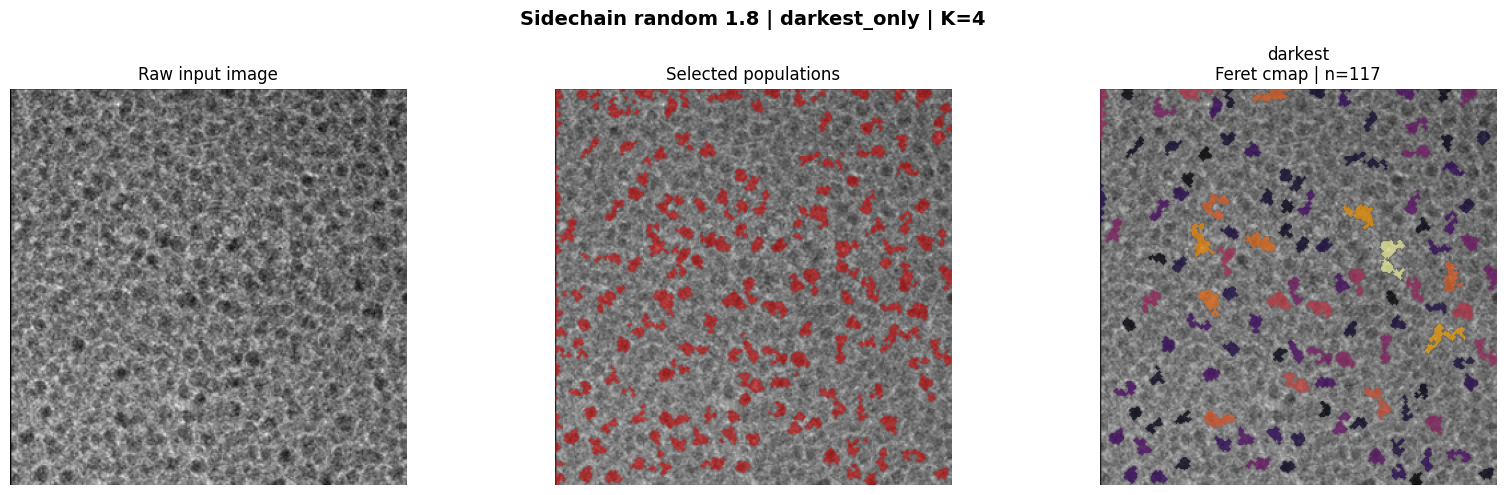


Processing: Sidechain block
Image size: 149 × 148 px
Pixel size: 0.6734 nm/px
Class mean intensities: [0.42920453 0.65276862 0.18229251 0.88713981]
Classes sorted darkest → brightest: [2 0 1 3]
  Population: darkest | KMeans class: 2
    Features after size filter: 27


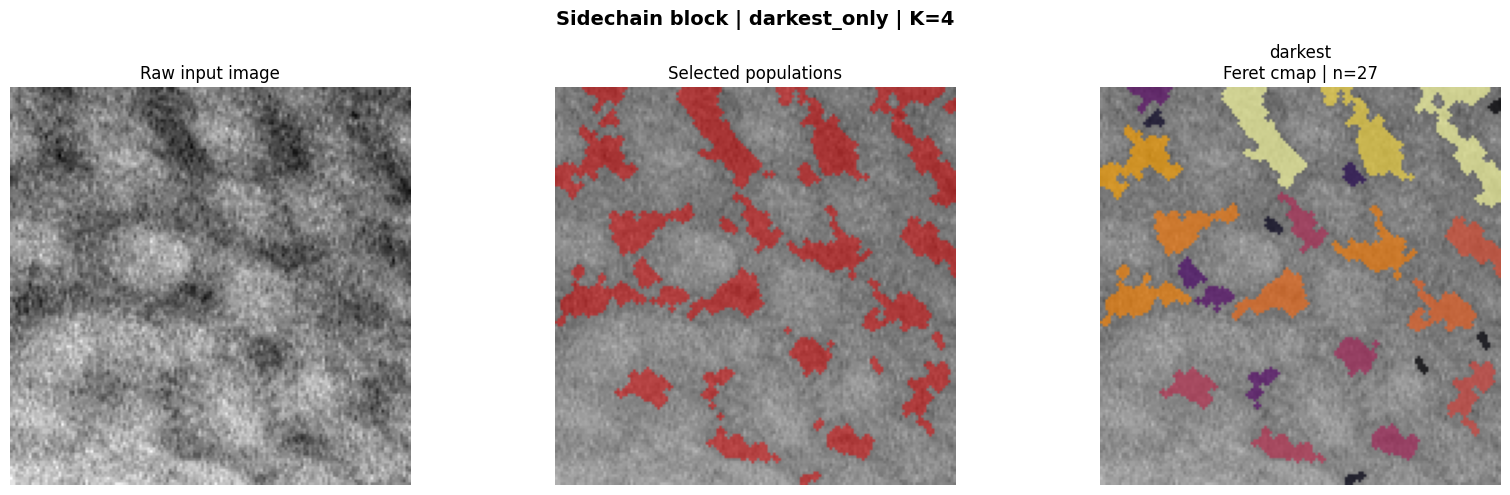


Processing: Backbone block
Image size: 298 × 297 px
Pixel size: 0.3361 nm/px
Class mean intensities: [0.62918113 0.37906298 0.87779315 0.12563253]
Classes sorted darkest → brightest: [3 1 0 2]
  Population: darkest | KMeans class: 3
    Features after size filter: 114


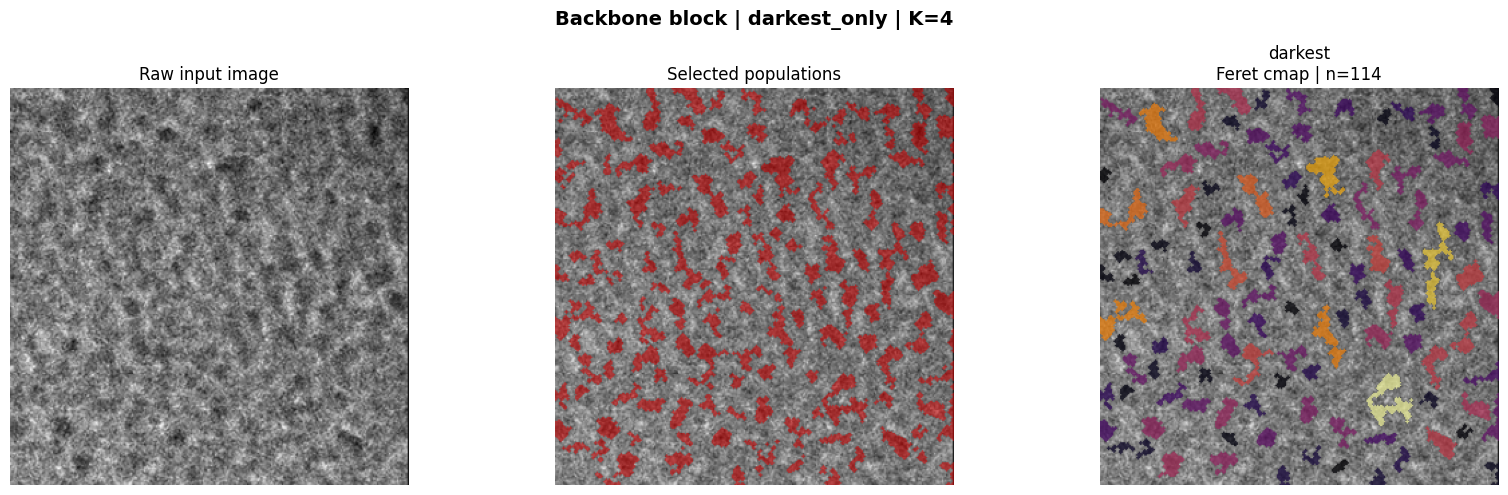


Processing: Nafion 212
Image size: 442 × 442 px
Pixel size: 0.2262 nm/px
Class mean intensities: [0.63086507 0.3806398  0.87930355 0.12841426]
Classes sorted darkest → brightest: [3 1 0 2]
  Population: darkest | KMeans class: 3
    Features after size filter: 91


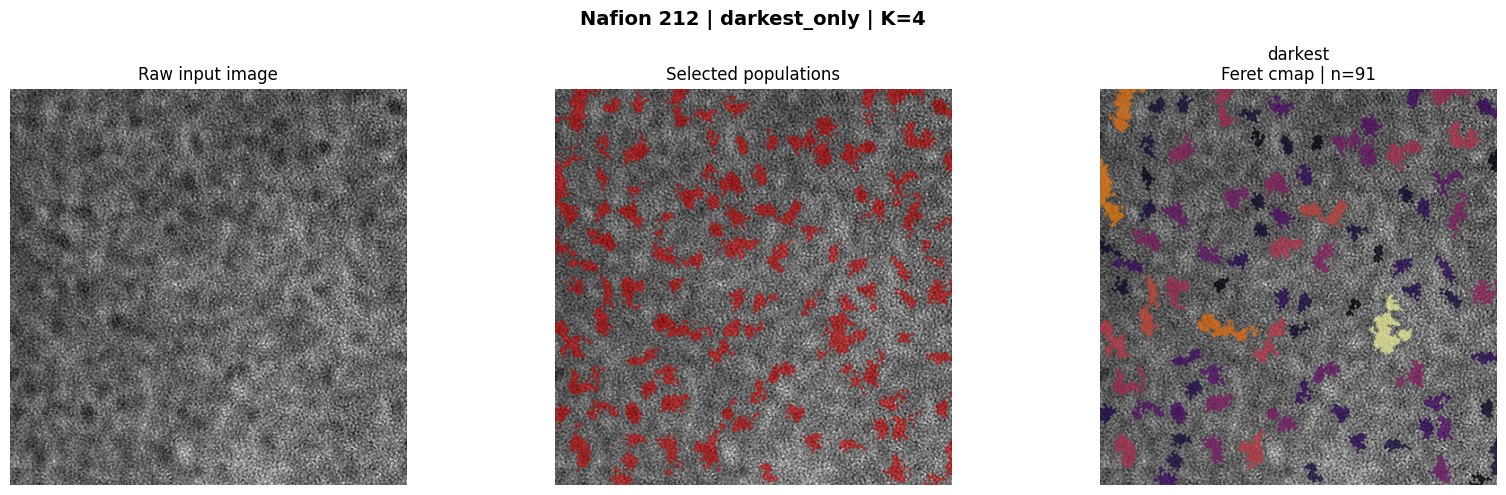

In [13]:
# ------------------------------------------------------------
# Batch-wise Image Analysis
# ------------------------------------------------------------
all_feature_tables = []
skipped_records = []

for path in image_paths:
    image_name = os.path.splitext(os.path.basename(path))[0]
    print(f"\nProcessing: {image_name}")
    # ----------------------------
    # Read and calibrate image
    # ----------------------------
    img_raw_display = read_grayscale_image_raw_display(path)
    img = read_grayscale_image(path)
    height_px, width_px = img.shape
    pixel_size_x_nm = fov_nm_x / width_px
    pixel_size_y_nm = fov_nm_y / height_px
    pixel_size_nm = 0.5 * (pixel_size_x_nm + pixel_size_y_nm)

    print(f"Image size: {width_px} × {height_px} px")
    print(f"Pixel size: {pixel_size_nm:.4f} nm/px")

    # ----------------------------
    # Preprocessing
    # ----------------------------
    img_proc = contrast_preprocess(
        img,
        use_clahe=use_clahe,
        use_smoothing=use_smoothing,
        smoothing_method=smoothing_method,
        gaussian_sigma=gaussian_sigma,
        median_radius=median_radius,
        clip_limit=clip_limit
    )

    # ----------------------------
    # Segmentation
    # ----------------------------
    labels, class_means, sorted_classes = kmeans_segment_classes(
        img_proc,
        n_classes=n_classes,
        random_state=random_state
    )
    print("Class mean intensities:", class_means)
    print("Classes sorted darkest → brightest:", sorted_classes)

    selected_populations = get_selected_populations(
        sorted_classes,
        population_mode=population_mode
    )

    # ----------------------------
    # Processing selected populations (darkest or top two darkest segments)
    # ----------------------------
    valid_population_tables = []
    population_masks_for_overlay = []
    population_domain_overlays = {}

    for pop in selected_populations:
        pop_name = pop["population_name"]
        pop_rank = pop["rank"]
        class_id = pop["class_id"]

        if use_kmeans_darkness_threshold:
            cluster_pixels = img_proc[labels == class_id]

            if darkness_metric == "mean":
                cluster_darkness_metric = float(np.mean(cluster_pixels))
            elif darkness_metric == "median":
                cluster_darkness_metric = float(np.median(cluster_pixels))
            elif darkness_metric == "p90":
                cluster_darkness_metric = float(np.percentile(cluster_pixels, 90))

            if pop_rank == 1:
                active_threshold = darkest_threshold
            elif pop_rank == 2:
                active_threshold = second_darkest_threshold
            else:
                active_threshold = darkest_threshold

            if cluster_darkness_metric > active_threshold:
                skipped_records.append({
                    "image": image_name,
                    "feature_population": pop_name,
                    "kmeans_class_id": class_id,
                    "n_features": 0,
                    "reason": (
                        f"KMeans darkness metric {cluster_darkness_metric:.4f} "
                        f"> {darkness_threshold_percentile}th-percentile threshold "
                        f"{active_threshold:.4f}"
                    )
                })

                print(
                    f"    Skipped by KMeans darkness threshold: "
                    f"{cluster_darkness_metric:.4f} > {active_threshold:.4f}"
                )

                continue

        cmap_name = pop["cmap"]
        mask_color = pop["mask_color"]

        print(f"  Population: {pop_name} | KMeans class: {class_id}")

        class_mean_intensity = class_means[class_id]
        raw_mask = labels == class_id


        raw_mask, rescue_mask, rescue_threshold = add_dark_pixel_rescue_mask(
            raw_mask,
            img_proc,
            dark_percentile=8,
            connection_radius_px=1
        )

        if remove_border:
            raw_mask = segmentation.clear_border(raw_mask)

        clean_pop_mask, min_area_pixels = clean_mask(
            raw_mask,
            pixel_size_nm=pixel_size_nm,
            min_feature_diameter_nm=min_feature_size_nm
        )

        df_pop, labeled_pop = measure_features(
            clean_pop_mask,
            img_original=img,
            pixel_size_nm=pixel_size_nm,
            image_name=image_name,
            feature_population=pop_name,
            feature_class_rank=pop_rank,
            kmeans_class_id=class_id,
            size_filter_column=size_filter_column,
            min_feature_size_nm=min_feature_size_nm,
            max_feature_size_nm=max_feature_size_nm
        )

        print(f"    Features after size filter: {len(df_pop)}")

        # Filtering population based on valid features
        if len(df_pop) < min_features_required:
            skipped_records.append({
                "image": image_name,
                "feature_population": pop_name,
                "kmeans_class_id": class_id,
                "n_features": len(df_pop),
                "reason": f"< {min_features_required} features"
            })

            print(f"    Skipped: < {min_features_required} features")
            continue

        df_pop["n_classes"] = n_classes
        df_pop["pixel_size_nm"] = pixel_size_nm
        df_pop["min_feature_size_nm"] = min_feature_size_nm
        df_pop["size_filter_column"] = size_filter_column
        df_pop["population_mode"] = population_mode

        valid_population_tables.append(df_pop)

        population_masks_for_overlay.append({
            "mask": clean_pop_mask,
            "mask_color": mask_color,
            "population_name": pop_name
        })

        # Domain-shape colormap overlay
        domain_overlay = make_domain_colormap_overlay(
            img_raw_display,
            labeled_pop,
            df_pop,
            size_column=size_column_for_colormap,
            cmap_name='inferno',
            alpha=domain_alpha
        )

        population_domain_overlays[pop_name] = {
            "overlay": domain_overlay,
            "df": df_pop,
            "cmap": 'inferno',
            "label": f"{pop_name} Feret diameter (nm)"
        }

        # Save binary mask
        io.imsave(
            os.path.join(
                output_folder,
                f"{image_name}_{pop_name}_binary_mask.png"
            ),
            (255 * clean_pop_mask).astype("uint8")
        )

        # Save simple mask overlay
        simple_mask_overlay = make_single_mask_overlay(
            img_raw_display,
            clean_pop_mask,
            color_name=mask_color,
            alpha=mask_alpha
        )

        io.imsave(
            os.path.join(
                output_folder,
                f"{image_name}_{pop_name}_mask_overlay.png"
            ),
            (255 * simple_mask_overlay).astype("uint8")
        )

        # Save domain colormap overlay with colorbar
        save_colormap_figure(
            original_img=img_raw_display,
            overlay=domain_overlay,
            df_features=df_pop,
            output_path=os.path.join(
                output_folder,
                f"{image_name}_{pop_name}_domain_{cmap_name}_feret_colormap.png"
            ),
            size_column=size_column_for_colormap,
            cmap_name='inferno',
            colorbar_label=f"{pop_name} equivalent diameter (nm)",
            base_alpha=0.99,
            dpi=300
        )
        # Optional number/circle annotation overlay
        if make_number_or_circle_overlay:
            annotation_overlay = make_population_annotation_overlay(
                img,
                df_pop,
                pixel_size_nm=pixel_size_nm,
                annotation_mode=annotation_mode,
                size_column=size_column_for_colormap,
                cmap_name='inferno',
                font_scale=0.4,
                thickness=1
            )

            save_colormap_figure(
                original_img=img_raw_display,
                overlay=annotation_overlay,
                df_features=df_pop,
                output_path=os.path.join(
                    output_folder,
                    f"{image_name}_{pop_name}_domain_{cmap_name}_feret_colormap.png"
                ),
                size_column=size_column_for_colormap,
                cmap_name=cmap_name,
                colorbar_label=f"{pop_name} Feret diameter (nm)",
                base_alpha=0.99,
                dpi=300
            )

    # ----------------------------
    # Skipping image if no selected population passed filters
    # ----------------------------

    if len(valid_population_tables) == 0:
        print(f"Skipping {image_name}: no valid populations.")
        continue

    df_valid_image = pd.concat(valid_population_tables, ignore_index=True)
    all_feature_tables.append(df_valid_image)

    # ----------------------------
    # Save combined population visualization
    # ----------------------------

    multi_population_overlay = make_multi_population_overlay(
        img_raw_display,
        population_masks_for_overlay,
        alpha=mask_alpha
    )

    io.imsave(
        os.path.join(
            output_folder,
            f"{image_name}_{population_mode}_population_overlay.png"
        ),
        (255 * multi_population_overlay).astype("uint8")
    )

    # ----------------------------
    # Display in notebook
    # ----------------------------

    if display_images:
        n_panels = 2 + len(population_domain_overlays)

        fig, axes = plt.subplots(
            1,
            n_panels,
            figsize=(5.5 * n_panels, 5)
        )

        if n_panels == 1:
            axes = [axes]

        axes[0].imshow(img_raw_display, cmap="gray")
        axes[0].set_title("Raw input image")
        axes[0].axis("off")

        axes[1].imshow(multi_population_overlay)
        axes[1].set_title("Selected populations")
        axes[1].axis("off")

        panel_idx = 2

        for pop_name, overlay_data in population_domain_overlays.items():
            df_pop = overlay_data["df"]
            axes[panel_idx].imshow(overlay_data["overlay"])
            axes[panel_idx].set_title(
                f"{pop_name}\nFeret cmap | n={len(df_pop)}"
            )
            axes[panel_idx].axis("off")
            panel_idx += 1

        fig.suptitle(
            f"{image_name} | {population_mode} | K={n_classes}",
            fontsize=14,
            fontweight="bold"
        )

        plt.tight_layout()
        plt.show()

In [14]:
# ------------------------------------------------------------
# Combine accepted feature tables
# ------------------------------------------------------------
if len(all_feature_tables) > 0:
    df_all = pd.concat(all_feature_tables, ignore_index=True)
else:
    df_all = pd.DataFrame()

df_all.head()

,image,feature_population,feature_class_rank,kmeans_class_id,feature_id,area_px,area_nm2,equivalent_diameter_nm,feret_diameter_max_nm,major_axis_length_nm,...,solidity,extent,centroid_y_px,centroid_x_px,mean_intensity,n_classes,pixel_size_nm,min_feature_size_nm,size_filter_column,population_mode
0,Sidechain random 1.8,darkest,1,1,1,128.0,14.413765,4.283944,13.527278,15.022871,...,0.612440,0.533333,16.171875,1.484375,0.210197,4,0.33557,3,equivalent_diameter_nm,darkest_only
1,Sidechain random 1.8,darkest,1,1,2,66.0,7.432098,3.076173,3.751792,3.278290,...,0.868421,0.733333,3.545455,20.333333,0.247229,4,0.33557,3,equivalent_diameter_nm,darkest_only
2,Sidechain random 1.8,darkest,1,1,5,142.0,15.990271,4.512144,10.738255,10.127994,...,0.685990,0.443750,2.676056,70.619718,0.242116,4,0.33557,3,equivalent_diameter_nm,darkest_only
3,Sidechain random 1.8,darkest,1,1,6,70.0,7.882528,3.168019,5.554680,6.436282,...,0.614035,0.466667,6.371429,96.357143,0.227227,4,0.33557,3,equivalent_diameter_nm,darkest_only
4,Sidechain random 1.8,darkest,1,1,9,169.0,19.030674,4.922459,10.095040,9.575853,...,0.719149,0.529781,4.644970,128.816568,0.200847,4,0.33557,3,equivalent_diameter_nm,darkest_only


In [15]:
# ------------------------------------------------------------
# Skipped populations table
# ------------------------------------------------------------
df_skipped = pd.DataFrame(skipped_records)
df_skipped

,image,feature_population,kmeans_class_id,n_features,reason
0,Backbone random,darkest,2,5,< 25 features
1,Sidechain random 1.5,darkest,2,22,< 25 features


In [16]:
summary_combined = summarize_features_combined_by_image(
    df_all,
    min_features_for_summary=min_features_for_summary,
    min_median_size_for_summary=min_median_size_for_summary,
    size_column_for_filter=size_filter_column
)

summary_combined

,image,n_features,mean_equiv_diameter_nm,median_equiv_diameter_nm,std_equiv_diameter_nm,mean_feret_diameter_max_nm,median_feret_diameter_max_nm,std_feret_diameter_max_nm,mean_major_axis_nm,median_major_axis_nm,mean_minor_axis_nm,median_minor_axis_nm,mean_aspect_ratio,median_aspect_ratio,mean_circularity,median_circularity,mean_solidity,median_solidity,total_area_nm2
0,Backbone block,114,4.582752,4.455598,1.216534,7.729793,6.859685,3.112314,7.747074,6.748967,3.946230,3.719819,1.995637,1.804581,0.473388,0.448231,0.704324,0.718589,2011.733701
1,Nafion 212,91,4.584808,4.279430,1.153463,7.681375,6.969648,2.699048,7.376800,6.510621,3.979881,3.856500,1.905306,1.724258,0.336745,0.330689,0.677150,0.673239,1596.404660
2,Sidechain block,27,9.140358,9.460180,4.167744,15.440536,14.876076,8.744465,15.183517,13.022857,7.494998,7.076708,2.000784,1.923162,0.563891,0.486096,0.748295,0.744395,2126.361853
3,Sidechain random 1.8,117,3.700384,3.511462,0.616172,5.838329,5.410911,1.824298,5.808023,5.192412,3.106105,3.035182,1.960426,1.777841,0.599822,0.605408,0.774240,0.787037,1292.847169


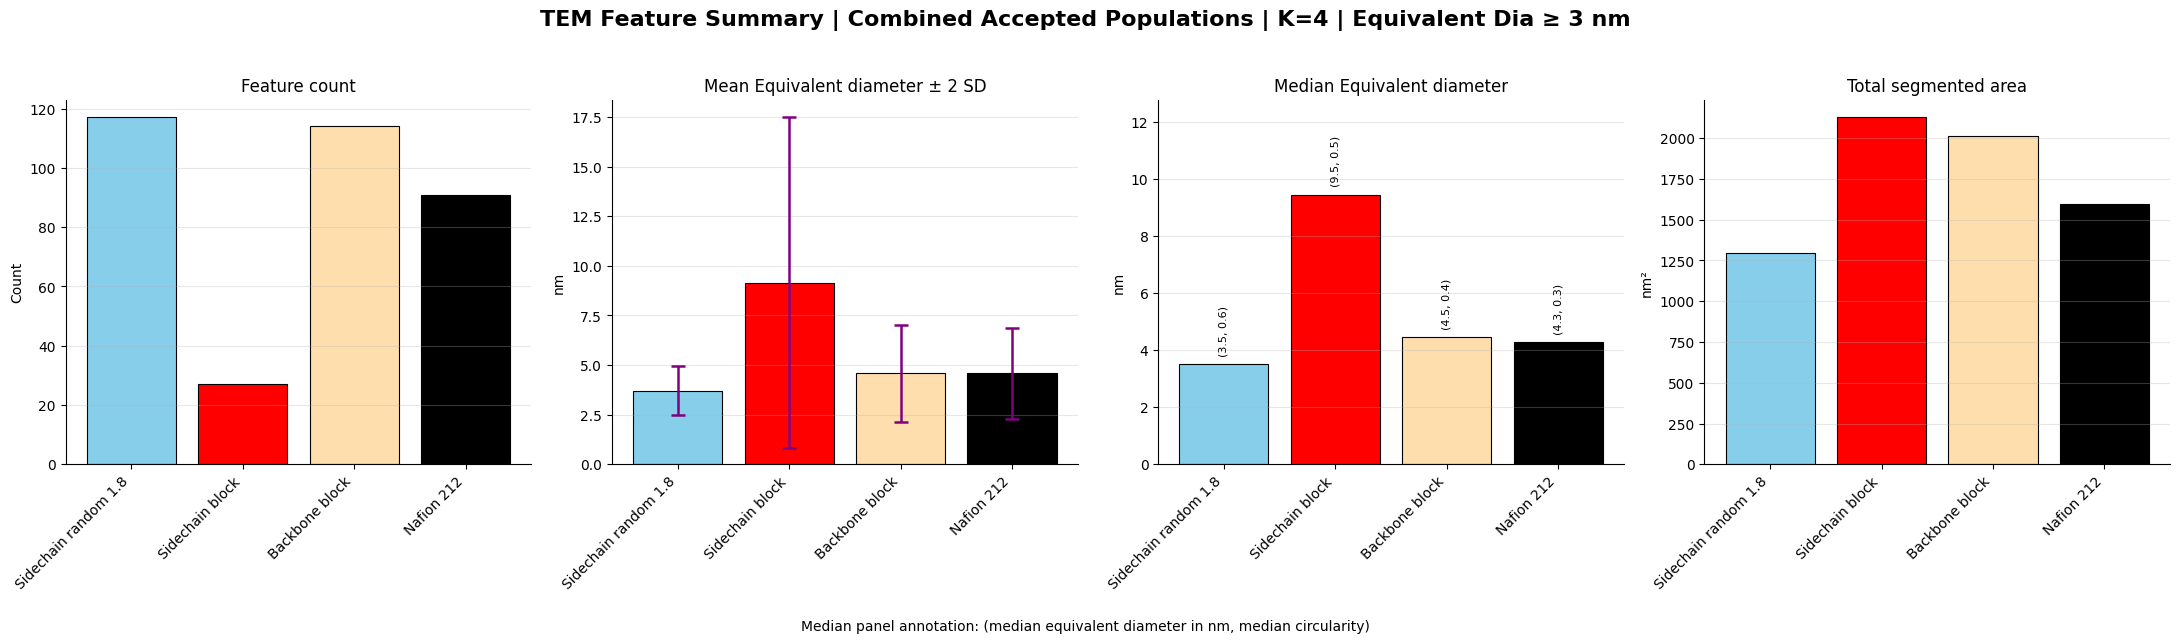

In [17]:
plot_summary_combined_by_image(
    summary_combined,
    output_path=os.path.join(
        output_folder,
        "TEM_summary_combined_by_image.png"
    ),
    title=(
        f"TEM Feature Summary | Combined Accepted Populations | "
        f"K={n_classes} | Equivalent Dia ≥ {min_feature_size_nm} nm"
    ),
    size_metric=None
)

In [18]:
# ------------------------------------------------------------
# Nearest-neighbor distance analysis
# ------------------------------------------------------------
# If population_mode = "darkest_plus_second", distances are calculated separately
# for each population unless group_cols are changed.

df_distances = compute_nearest_neighbor_distances(
    df_all,
    pixel_size_column="pixel_size_nm",
    x_col="centroid_x_px",
    y_col="centroid_y_px",
    size_col="equivalent_diameter_nm",
    group_cols=("image", "feature_population")
)

df_distances.head()

,image,feature_population,feature_id,nearest_neighbor_feature_id,nearest_centroid_distance_nm,nearest_edge_gap_nm,feature_equiv_diameter_nm,nearest_neighbor_equiv_diameter_nm,centroid_x_nm,centroid_y_nm,nearest_centroid_x_nm,nearest_centroid_y_nm,n_classes,min_feature_size_nm,size_filter_column,population_mode
0,Backbone block,darkest,1,14,8.996139,4.374224,5.851373,3.392457,24.232820,5.924740,32.895051,8.352965,4,3,equivalent_diameter_nm,darkest_only
1,Backbone block,darkest,2,14,5.831311,1.265247,5.739672,3.392457,34.252051,2.681744,32.895051,8.352965,4,3,equivalent_diameter_nm,darkest_only
2,Backbone block,darkest,3,21,7.893862,3.438264,4.471742,4.439454,49.706930,3.046983,50.611687,10.888824,4,3,equivalent_diameter_nm,darkest_only
3,Backbone block,darkest,4,5,7.438960,3.514065,4.722100,3.127691,91.875564,3.682309,99.070967,1.794370,4,3,equivalent_diameter_nm,darkest_only
4,Backbone block,darkest,5,4,7.438960,3.514065,3.127691,4.722100,99.070967,1.794370,91.875564,3.682309,4,3,equivalent_diameter_nm,darkest_only


In [19]:
# ------------------------------------------------------------
# Summarize nearest-neighbor distances
# ------------------------------------------------------------

distance_summary = summarize_nearest_neighbor_distances(
    df_distances,
    group_cols=("image", "feature_population")
)

distance_summary

,image,feature_population,n_features_with_distance,mean_nearest_centroid_distance_nm,median_nearest_centroid_distance_nm,std_nearest_centroid_distance_nm,mean_nearest_edge_gap_nm,median_nearest_edge_gap_nm,std_nearest_edge_gap_nm
0,Backbone block,darkest,114,7.169142,6.922006,1.478195,2.661603,2.497232,1.374099
1,Nafion 212,darkest,91,7.770171,7.582384,1.806100,3.366674,3.141627,1.622585
2,Sidechain block,darkest,27,12.988525,12.654091,4.268596,4.812306,5.032471,3.657034
3,Sidechain random 1.8,darkest,117,6.594527,6.589608,1.536400,2.981419,2.758477,1.451334


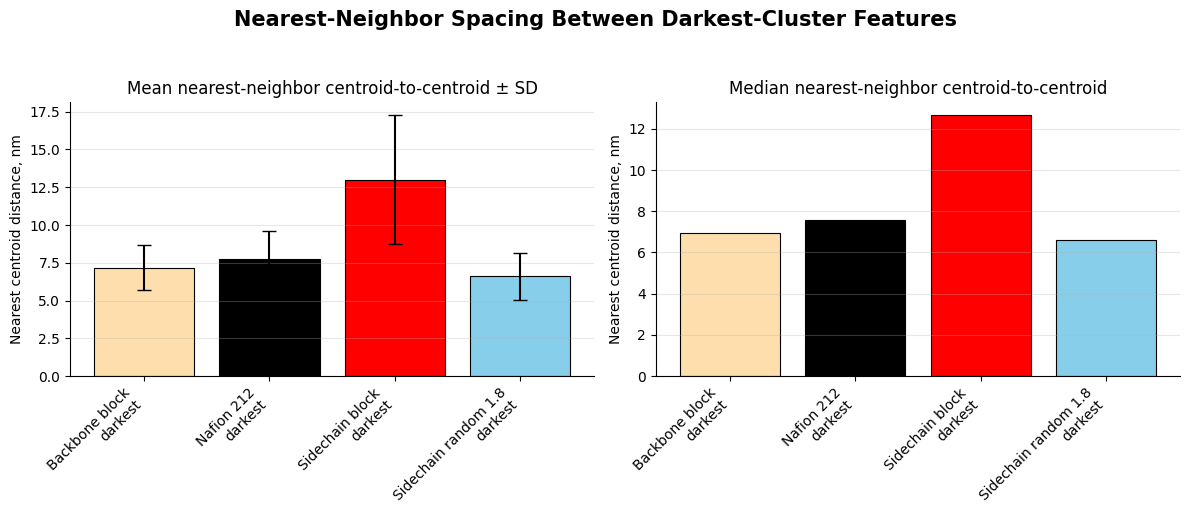

In [20]:
plot_nearest_neighbor_distance_summary(
    distance_summary,
    output_path=os.path.join(
        output_folder,
        "TEM_nearest_neighbor_centroid_distance_summary.png"
    ),
    distance_metric="centroid",  # use "centroid" for approximate centroid-to-centroid distance
    title="Nearest-Neighbor Spacing Between Darkest-Cluster Features"
)

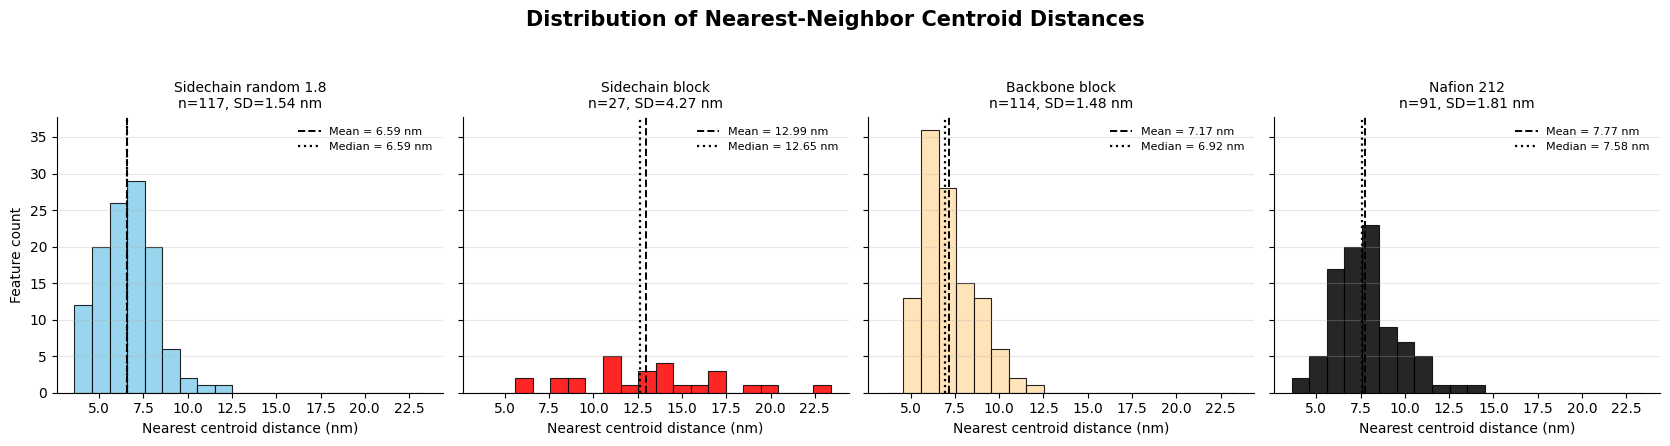

In [21]:
plot_nearest_centroid_distance_histograms(
    df_distances,
    output_path=os.path.join(
        output_folder,
        "TEM_nearest_centroid_distance_histograms_by_sample.png"
    ),
    bins=20,
    distance_col="nearest_centroid_distance_nm",
    population_filter="darkest",
    title="Distribution of Nearest-Neighbor Centroid Distances"
)

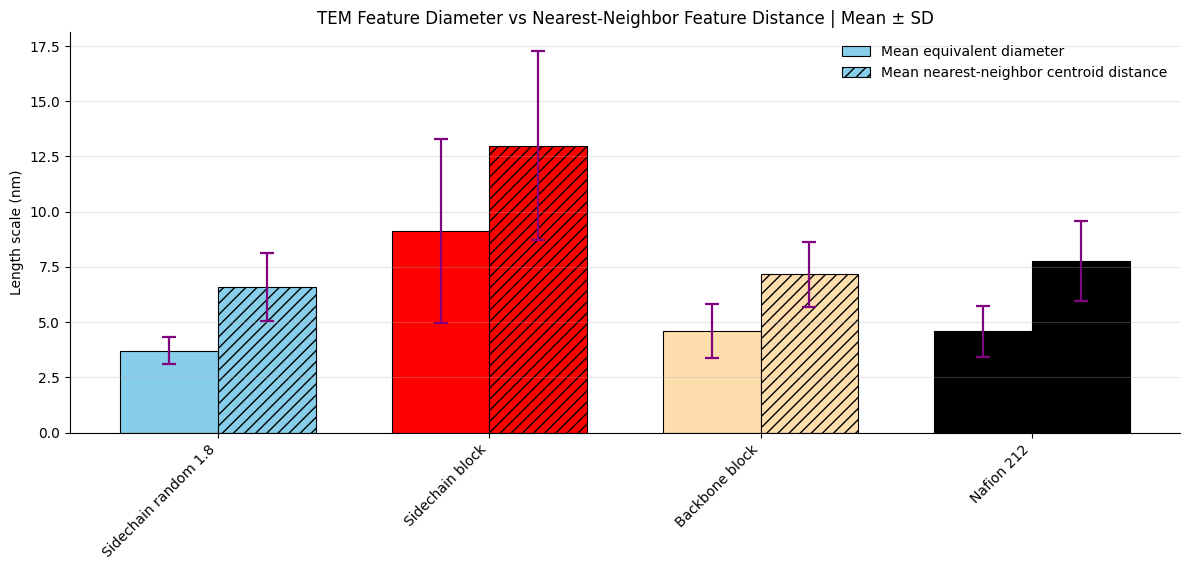

In [22]:
plot_feature_diameter_vs_distance(
    feature_summary=summary_combined,
    distance_summary=distance_summary,
    output_path=os.path.join(
        output_folder,
        "TEM_mean_feature_diameter_vs_nearest_neighbor_distance_with_SD.png"
    ),
    statistic="mean",
    diameter_metric="equivalent",
    distance_metric="centroid",
    distance_population="darkest",
    title="TEM Feature Diameter vs Nearest-Neighbor Feature Distance",
    errorbar_color="purple"
)

In [ ]:
# Removing the raw files
for f in glob.glob("TEM_images/*"):
    os.remove(f)